In [1]:
pip install pandas matplotlib scikit-learn

In [3]:
from google.colab import files

uploaded = files.upload()

Saving hospital_weather_patient_arrivals.csv to hospital_weather_patient_arrivals.csv


In [4]:
import pandas as pd

df = pd.read_csv("hospital_weather_patient_arrivals.csv")

print(df.head())

         Date        Department  Outpatient_Count  Emergency_Count  \
0  2024-01-01  General Medicine                61               11   
1  2024-01-01        Pediatrics                51               10   
2  2024-01-01       Respiratory                45               10   
3  2024-01-01       Orthopedics                43               12   
4  2024-01-01        Cardiology                35               14   

   Temperature  Rainfall  Humidity  Air_Quality  
0         25.7       4.7      72.3           95  
1         25.7       4.7      72.3           95  
2         25.7       4.7      72.3           95  
3         25.7       4.7      72.3           95  
4         25.7       4.7      72.3           95  



Dataset:
         Date        Department  Outpatient_Count  Emergency_Count  \
0  2024-01-01  General Medicine                61               11   
1  2024-01-01        Pediatrics                51               10   
2  2024-01-01       Respiratory                45               10   
3  2024-01-01       Orthopedics                43               12   
4  2024-01-01        Cardiology                35               14   

   Temperature  Rainfall  Humidity  Air_Quality  Total_Patients  
0         25.7       4.7      72.3           95              72  
1         25.7       4.7      72.3           95              61  
2         25.7       4.7      72.3           95              55  
3         25.7       4.7      72.3           95              55  
4         25.7       4.7      72.3           95              49  

Statistics:
       Outpatient_Count  Emergency_Count  Temperature     Rainfall  \
count       3655.000000      3655.000000  3655.000000  3655.000000   
mean          45.281

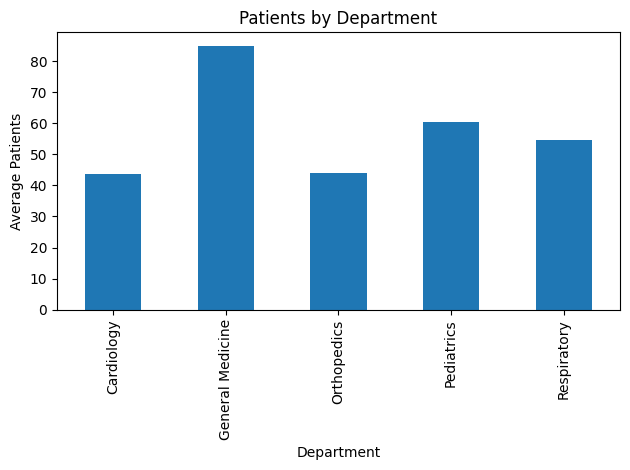

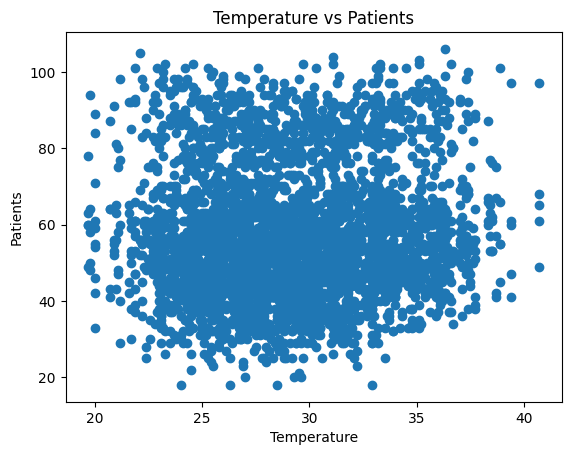

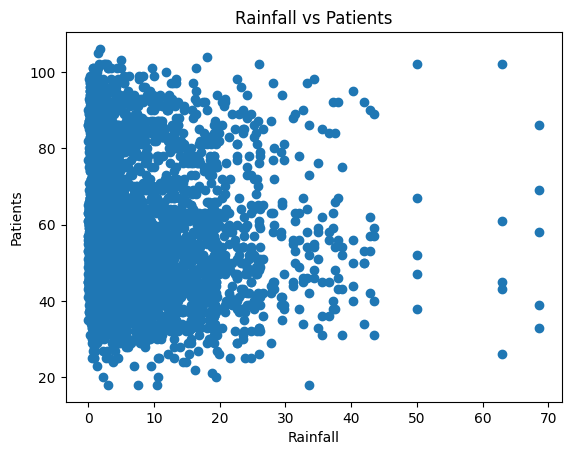

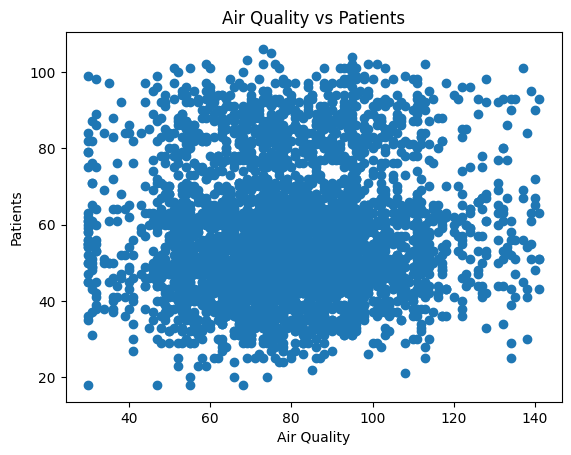


MODEL RESULT
MAE: 13.781533903265212
R2 Score: -0.003925672587564266


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load data
df = pd.read_csv("hospital_weather_patient_arrivals.csv")
df = df.dropna()

# Total patients
df["Total_Patients"] = df["Outpatient_Count"] + df["Emergency_Count"]

print("\nDataset:")
print(df.head())

print("\nStatistics:")
print(df.describe())

# 2. Visualization 1
df.groupby("Department")["Total_Patients"].mean().plot(kind="bar")
plt.title("Patients by Department")
plt.ylabel("Average Patients")
plt.tight_layout()
plt.show()

# 3. Visualization 2
plt.scatter(df["Temperature"], df["Total_Patients"])
plt.xlabel("Temperature")
plt.ylabel("Patients")
plt.title("Temperature vs Patients")
plt.show()

# 4. Visualization 3
plt.scatter(df["Rainfall"], df["Total_Patients"])
plt.xlabel("Rainfall")
plt.ylabel("Patients")
plt.title("Rainfall vs Patients")
plt.show()

# 5. Visualization 4
plt.scatter(df["Air_Quality"], df["Total_Patients"])
plt.xlabel("Air Quality")
plt.ylabel("Patients")
plt.title("Air Quality vs Patients")
plt.show()

# Linear Regression
X = df[["Temperature", "Rainfall", "Humidity", "Air_Quality"]]
y = df["Total_Patients"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("\nMODEL RESULT")
print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))